# **Prediction of Magnetic Ordering Temperature in Perovskite related Magnetic compounds using Matminer for feature generation and Gradient Boosting for prediction**

# Data Cleaning

In [1]:
import pandas as pd

df = pd.read_csv("perovskites_clean.csv")

In [2]:
df.head()

,Crystal_Structure,Lattice_Parameters,formula,TN,Space_Group
0,Perovskite,NaN,Nd0.5Sr0.5MnO3,50.0,NaN
1,Layered Perovskite,"{'a': '3.8699 Ã…', 'c': '7.6359 Ã…'}",YBaCuFe0.95Mn0.05O5,331.0,P4mm
2,Layered Perovskite,"{'a': '3.8735 Ã…', 'c': '7.6648 Ã…'}",YBaCuFeO5,306.5,P4mm
3,Orthorhombic Perovskite,NaN,Nd0.93MnO2.96,80.0,Pnma
4,Perovskite,NaN,Nd0.5Sr0.5MnO3,225.0,NaN


In [3]:
df.shape



(224, 5)

In [4]:
df.isnull().sum()

Crystal_Structure       0
Lattice_Parameters    113
formula                 0
TN                      0
Space_Group            83
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["TN"].describe()

count    224.000000
mean     201.019018
std      211.455116
min        0.910000
25%       46.000000
50%      129.000000
75%      254.250000
max      750.000000
Name: TN, dtype: float64

In [7]:
df.head()

,Crystal_Structure,Lattice_Parameters,formula,TN,Space_Group
0,Perovskite,NaN,Nd0.5Sr0.5MnO3,50.0,NaN
1,Layered Perovskite,"{'a': '3.8699 Ã…', 'c': '7.6359 Ã…'}",YBaCuFe0.95Mn0.05O5,331.0,P4mm
2,Layered Perovskite,"{'a': '3.8735 Ã…', 'c': '7.6648 Ã…'}",YBaCuFeO5,306.5,P4mm
3,Orthorhombic Perovskite,NaN,Nd0.93MnO2.96,80.0,Pnma
4,Perovskite,NaN,Nd0.5Sr0.5MnO3,225.0,NaN


In [8]:
df.iloc[:, -3:]

,formula,TN,Space_Group
0,Nd0.5Sr0.5MnO3,50.0,NaN
1,YBaCuFe0.95Mn0.05O5,331.0,P4mm
2,YBaCuFeO5,306.5,P4mm
3,Nd0.93MnO2.96,80.0,Pnma
4,Nd0.5Sr0.5MnO3,225.0,NaN
...,...,...,...
219,Sm0.3Tb0.7FeO3,385.0,Pbnm
220,Pr0.6Ca0.4MnO3,170.0,Pbnm
221,Ca0.97Pr0.03MnO3,97.0,NaN
222,Ca0.94Pr0.06MnO3,125.0,NaN


In [9]:
df.to_csv(
    "perovskites_clean.csv",
    index=False
)


# Feature Extraction using matminer

In [10]:
df["formula"]=df["formula"].astype(str)

In [11]:
df["formula"].dtype

dtype('O')

In [12]:
unique_types = df['formula'].apply(type).unique()
print(f"Unique data types in the 'formula' column: {unique_types}")

Unique data types in the 'formula' column: [<class 'str'>]


installing matminer

In [13]:
!pip install matminer pymatgen

turning the column values into composition to make it matminer extractable

In [14]:
from pymatgen.core import Composition

def safe_composition(formula):
    try:
        return Composition(str(formula))
    except Exception:
        return None

df["composition"] = df["formula"].apply(safe_composition)

In [15]:
Composition("SmFeO3")

Composition('Sm1 Fe1 O3')

Feauturization of compositions using elemental properties that shall produce 145 descriptors

In [ ]:
from matminer.featurizers.composition import ElementProperty

ep = ElementProperty.from_preset("magpie") #magpie is on database of elemental properties

#goes through my dataframe and featurizes
df = ep.featurize_dataframe(
    df,
    col_id="composition",
    ignore_errors=True
)

c:\Users\sanja\anaconda3\envs\cwq\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ElementProperty: 100%|██████████| 224/224 [00:23<00:00,  9.44it/s]


In [ ]:
df.columns

Index(['Crystal_Structure', 'Lattice_Parameters', 'formula', 'TN',
       'Space_Group', 'composition', 'MagpieData minimum Number',
       'MagpieData maximum Number', 'MagpieData range Number',
       'MagpieData mean Number',
       ...
       'MagpieData range GSmagmom', 'MagpieData mean GSmagmom',
       'MagpieData avg_dev GSmagmom', 'MagpieData mode GSmagmom',
       'MagpieData minimum SpaceGroupNumber',
       'MagpieData maximum SpaceGroupNumber',
       'MagpieData range SpaceGroupNumber', 'MagpieData mean SpaceGroupNumber',
       'MagpieData avg_dev SpaceGroupNumber',
       'MagpieData mode SpaceGroupNumber'],
      dtype='object', length=138)

In [ ]:
df.shape

(224, 138)

In [ ]:
df.to_csv(
    "perovskites_magpie.csv",
    index=False
)

creating target and descriptor data

In [ ]:
X=df.drop(columns=["Crystal_Structure","Lattice_Parameters","formula","TN","Space_Group", "composition"])
y=df["TN"]

In [ ]:
X.dtypes

MagpieData minimum Number              float64
MagpieData maximum Number              float64
MagpieData range Number                float64
MagpieData mean Number                 float64
MagpieData avg_dev Number              float64
                                        ...   
MagpieData maximum SpaceGroupNumber    float64
MagpieData range SpaceGroupNumber      float64
MagpieData mean SpaceGroupNumber       float64
MagpieData avg_dev SpaceGroupNumber    float64
MagpieData mode SpaceGroupNumber       float64
Length: 132, dtype: object

In [ ]:
X = X.fillna(X.mean())

In [ ]:
X.isnull().sum()

MagpieData minimum Number              0
MagpieData maximum Number              0
MagpieData range Number                0
MagpieData mean Number                 0
MagpieData avg_dev Number              0
                                      ..
MagpieData maximum SpaceGroupNumber    0
MagpieData range SpaceGroupNumber      0
MagpieData mean SpaceGroupNumber       0
MagpieData avg_dev SpaceGroupNumber    0
MagpieData mode SpaceGroupNumber       0
Length: 132, dtype: int64

In [ ]:
y.isnull().sum()


np.int64(0)

In [ ]:
y=y.fillna(385)

Splitting data set using train test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Model 1: random forest generators


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [ ]:
pred_rf_test = rf.predict(X_test)
pred_rf_train = rf.predict(X_train)

running accuracy tests

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
print("random forest")
print("R² =", r2_score(y_train,pred_rf_train))
print("MAE =", mean_absolute_error(y_train, pred_rf_train))
print("R² =", r2_score(y_test,pred_rf_test))
print("MAE =", mean_absolute_error(y_test, pred_rf_test))

random forest
R² = 0.9659531952161804
MAE = 21.048933147113612
R² = 0.6476467589574035
MAE = 58.6736680026456


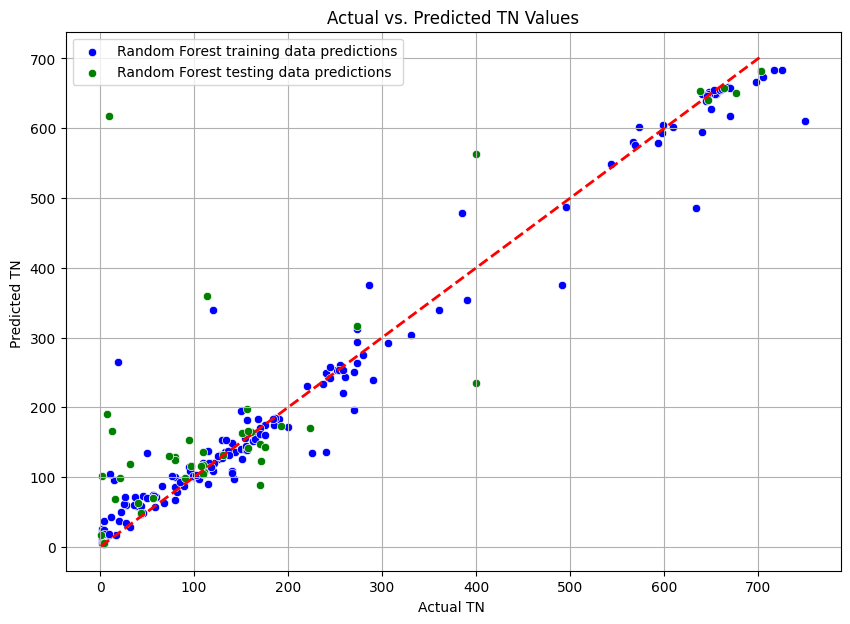

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_train, y=pred_rf_train, color='blue', label='Random Forest training data predictions')
sns.scatterplot(x=y_test, y=pred_rf_test, color='green', label='Random Forest testing data predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel("Actual TN ")
plt.ylabel("Predicted TN ")
plt.title("Actual vs. Predicted TN Values")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)
print(scores.mean())

0.441780666725111


In [ ]:
# Find the row for 'SmFeO3'
smfeo3_data = df[df['formula'] == 'SmFeO3']

# Extract the actual TN value for comparison
actual_tn_smfeo3 = smfeo3_data['TN'].values[0]

# Create a feature DataFrame for SmFeO3 by dropping the same columns as for X
X_smfeo3 = smfeo3_data.drop(columns=["Crystal_Structure", "Lattice_Parameters", "formula", "TN", "Space_Group", "composition"])

# Fill any missing values in X_smfeo3 using the mean of the original X DataFrame
# This ensures consistency with how the training data was preprocessed
X_smfeo3 = X_smfeo3.fillna(X.mean())

# Predict the TN value using the trained model
predicted_tn_smfeo3 = rf.predict(X_smfeo3)

print(f"Actual TN for SmFeO3: {actual_tn_smfeo3}")
print(f"Predicted TN for SmFeO3: {predicted_tn_smfeo3[0]:.2f}")

Actual TN for SmFeO3: 670.0
Predicted TN for SmFeO3: 617.77


Model 2: Extra trees Regressor

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42
)

et.fit(X_train, y_train)

pred_et_test = et.predict(X_test)
pred_et_train = et.predict(X_train)

print("Extra Trees")
print("testing data")
print("R² =", r2_score(y_test, pred_et_test))
print("MAE =", mean_absolute_error(y_test, pred_et_test))
print("training data")
print("R² =", r2_score(y_train, pred_et_train))
print("MAE =", mean_absolute_error(y_train, pred_et_train))

Extra Trees
testing data
R² = 0.7448751103660447
MAE = 51.76115308641972
training data
R² = 0.9955220740683532
MAE = 2.531750465549659


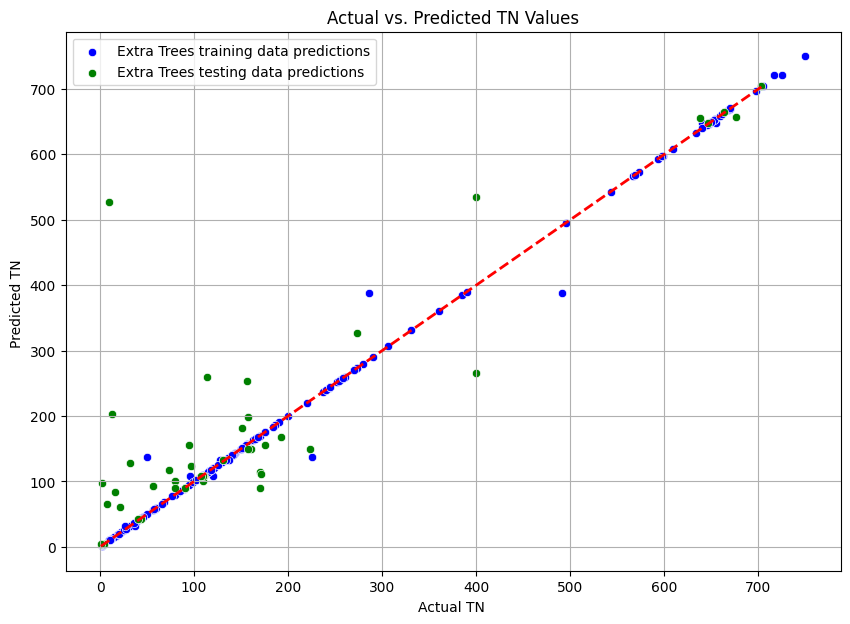

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_train, y=pred_et_train, color='blue', label='Extra Trees training data predictions')
sns.scatterplot(x=y_test, y=pred_et_test, color='green', label='Extra Trees testing data predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel("Actual TN ")
plt.ylabel("Predicted TN ")
plt.title("Actual vs. Predicted TN Values")
plt.grid(True)
plt.show()

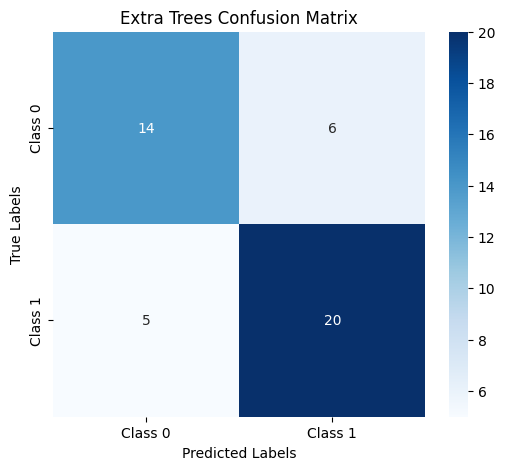

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the classification confusion matrix
threshold = y_test.median()
y_test_labels = (y_test >= threshold).astype(int)
y_pred_labels = (pred_et_test >= threshold).astype(int)

cm = confusion_matrix(y_test_labels, y_pred_labels)

# Plot as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Extra Trees Confusion Matrix')
plt.show()

Model 3: Gradient boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=42
)

gbr.fit(X_train, y_train)

pred_gbr_test = gbr.predict(X_test)
pred_gbr_train = gbr.predict(X_train)

print("Gradient Boosting")
print("R² =", r2_score(y_train, pred_gbr_train))
print("MAE =", mean_absolute_error(y_train, pred_gbr_train))
print("R² =", r2_score(y_test, pred_gbr_test))
print("MAE =", mean_absolute_error(y_test, pred_gbr_test))


Gradient Boosting
R² = 0.9906110507084271
MAE = 13.141778004676846
R² = 0.6631865412276865
MAE = 52.53159646916064


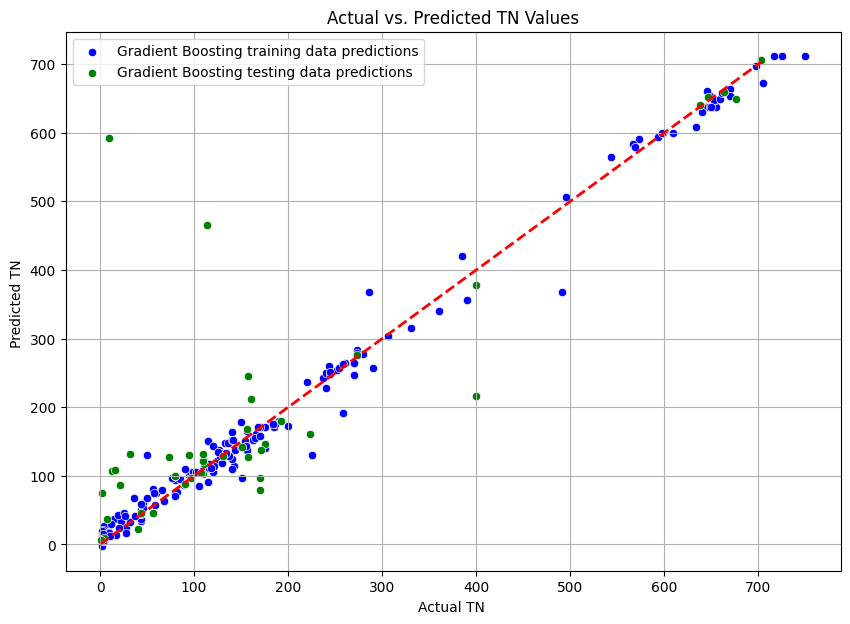

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_train, y=pred_gbr_train, color='blue', label='Gradient Boosting training data predictions')
sns.scatterplot(x=y_test, y=pred_gbr_test, color='green', label='Gradient Boosting testing data predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel("Actual TN ")
plt.ylabel("Predicted TN ")
plt.title("Actual vs. Predicted TN Values")
plt.grid(True)
plt.show()

Model 4: Xgboost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("XGBoost")
print("R² =", r2_score(y_test, pred))
print("MAE =", mean_absolute_error(y_test, pred))

XGBoost
R² = 0.595643600032877
MAE = 62.12919248029921


Model 5:Cat boost

In [ ]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
    --------------------------------------- 1.8/100.2 MB 9.1 MB/s eta 0:00:11
   - -------------------------------------- 3.7/100.2 MB 10.0 MB/s eta 0:00:10
   -- ------------------------------------- 5.8/100.2 MB 9.6 MB/s eta 0:00:10
   --- ------------------------------------ 7.6/100.2 MB 9.6 MB/s eta 0:00:10
   --- ------------------------------------ 9.2/100.2 MB 9.0 MB/s eta 0:00:11
   ---- ----------------------------------- 10.5/100.2 MB 8.5 MB/s eta 0:00:11
   ---- ----------------------------------- 12.1/100.2 MB 8.4 MB/s eta 0:00:11
   ----- ---------------------------------- 12.8/100.2 MB 7.8 MB/s eta 0:00:12
   ----- ---------------------------------- 14.4/100.2 MB 7.7 MB/s eta 0:00:12
   ------ --------------------------------- 17.0/100.2 MB 8.1 MB/s eta 0:00:11
   ------- -------------------------------- 19.1/100.2 MB 8.3 MB/s eta 0:00:10
   -------- ------------------------------- 21.2/100.2 MB 8.5 MB

In [ ]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    verbose=0,
    random_seed=42
)

cat.fit(X_train, y_train)

pred_cat_test = cat.predict(X_test)
pred_cat_train = cat.predict(X_train)

print("CatBoost")
print("R² =", r2_score(y_train, pred_cat_train))
print("MAE =", mean_absolute_error(y_train, pred_cat_train))
print("R² =", r2_score(y_test, pred_cat_test))
print("MAE =", mean_absolute_error(y_test, pred_cat_test))

CatBoost
R² = 0.994773101129785
MAE = 6.6717412168781784
R² = 0.7587935884277113
MAE = 51.95381177047596


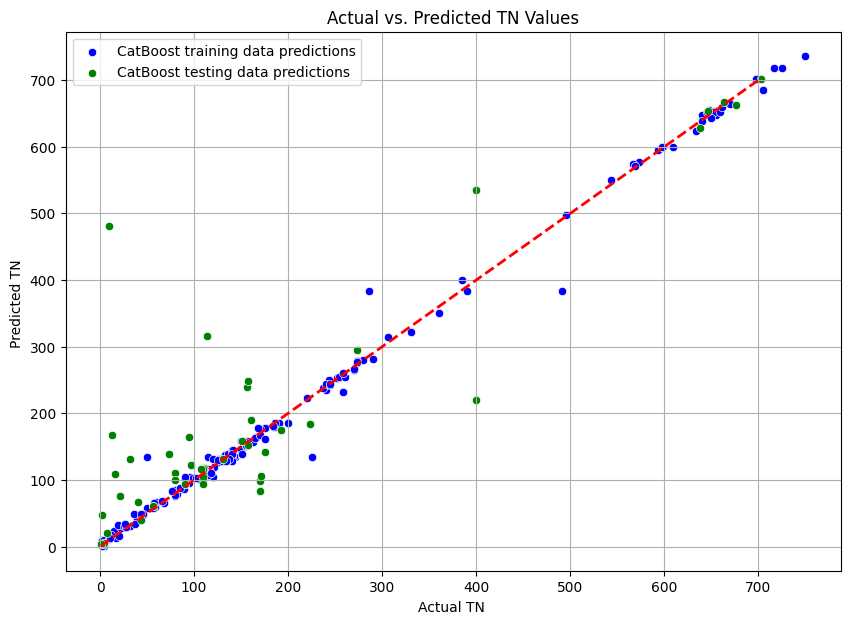

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_train, y=pred_cat_train, color='blue', label='CatBoost training data predictions')
sns.scatterplot(x=y_test, y=pred_cat_test, color='green', label='CatBoost testing data predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel("Actual TN ")
plt.ylabel("Predicted TN ")
plt.title("Actual vs. Predicted TN Values")
plt.grid(True)
plt.show()

Model 6: Support Vector Regression (SVR)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(C=10, epsilon=0.1))
])

svr.fit(X_train, y_train)

pred = svr.predict(X_test)

print("SVR")
print("R² =", r2_score(y_test, pred))
print("MAE =", mean_absolute_error(y_test, pred))

SVR
R² = 0.2209053381989785
MAE = 109.36349729516836


cross validation

In [ ]:
print(y.describe())

count    224.000000
mean     201.019018
std      211.455116
min        0.910000
25%       46.000000
50%      129.000000
75%      254.250000
max      750.000000
Name: TN, dtype: float64


In [ ]:
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    cat,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print(scores)
print(scores.mean())
print(scores.std())

[0.76586451 0.89310097 0.41151592 0.85535169 0.93804651]
0.7727759187236519
0.18929754046515332


In [ ]:
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    et,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print(scores)
print(scores.mean())
print(scores.std())

[0.77038509 0.80061591 0.45204543 0.81993625 0.88886835]
0.7463702048826496
0.15222619175978608


In [ ]:
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print(scores)
print(scores.mean())
print(scores.std())

[0.64774721 0.85138625 0.30622039 0.85470412 0.91275299]
0.7145621917081935
0.2230907656331411


RUN 2: getting more features

In [ ]:
df.to_csv("perovskites_magpie.csv", index=False)

In [ ]:
df_2 = df.copy()

In [ ]:
from matminer.featurizers.composition import Stoichiometry
stoich = Stoichiometry()

In [ ]:
df_2 = stoich.featurize_dataframe(
    df_2,
    "composition",
    ignore_errors=True
)

Stoichiometry: 100%|██████████| 224/224 [00:31<00:00,  7.15it/s]


In [ ]:
df_2.head()

,Crystal_Structure,Lattice_Parameters,formula,TN,Space_Group,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,...,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,0-norm,2-norm,3-norm,5-norm,7-norm,10-norm
0,Perovskite,NaN,Nd0.5Sr0.5MnO3,50.0,NaN,"(Nd, Sr, Mn, O)",8.0,60.0,52.0,19.600000,...,213.0,92.500000,96.600000,12.0,4,0.648074,0.609120,0.600524,0.600040,0.600001
1,Layered Perovskite,"{'a': '3.8699 Ã…', 'c': '7.6359 Ã…'}",YBaCuFe0.95Mn0.05O5,331.0,P4mm,"(Y, Ba, Cu, Fe, Mn, O)",8.0,56.0,48.0,21.105556,...,217.0,104.044444,102.271605,12.0,6,0.597371,0.561213,0.555690,0.555559,0.555556
2,Layered Perovskite,"{'a': '3.8735 Ã…', 'c': '7.6648 Ã…'}",YBaCuFeO5,306.5,P4mm,"(Y, Ba, Cu, Fe, O)",8.0,56.0,48.0,21.111111,...,217.0,104.111111,102.345679,12.0,5,0.598352,0.561419,0.555698,0.555560,0.555556
3,Orthorhombic Perovskite,NaN,Nd0.93MnO2.96,80.0,Pnma,"(Nd, Mn, O)",8.0,60.0,52.0,21.366053,...,205.0,88.535787,92.656822,12.0,3,0.666632,0.619042,0.606218,0.605387,0.605319
4,Perovskite,NaN,Nd0.5Sr0.5MnO3,225.0,NaN,"(Nd, Sr, Mn, O)",8.0,60.0,52.0,19.600000,...,213.0,92.500000,96.600000,12.0,4,0.648074,0.609120,0.600524,0.600040,0.600001


In [ ]:
from matminer.featurizers.composition import ValenceOrbital
vo = ValenceOrbital()
df_2 = vo.featurize_dataframe(
    df_2,
    "composition",
    ignore_errors=True
)

ValenceOrbital: 100%|██████████| 224/224 [00:35<00:00,  6.39it/s]


In [ ]:
df_2.head()

,Crystal_Structure,Lattice_Parameters,formula,TN,Space_Group,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,...,7-norm,10-norm,avg s valence electrons,avg p valence electrons,avg d valence electrons,avg f valence electrons,frac s valence electrons,frac p valence electrons,frac d valence electrons,frac f valence electrons
0,Perovskite,NaN,Nd0.5Sr0.5MnO3,50.0,NaN,"(Nd, Sr, Mn, O)",8.0,60.0,52.0,19.600000,...,0.600040,0.600001,2.000000,2.400000,1.000000,0.400000,0.344828,0.413793,0.172414,0.068966
1,Layered Perovskite,"{'a': '3.8699 Ã…', 'c': '7.6359 Ã…'}",YBaCuFe0.95Mn0.05O5,331.0,P4mm,"(Y, Ba, Cu, Fe, Mn, O)",8.0,56.0,48.0,21.105556,...,0.555559,0.555556,1.888889,2.222222,1.883333,0.000000,0.315107,0.370714,0.314180,0.000000
2,Layered Perovskite,"{'a': '3.8735 Ã…', 'c': '7.6648 Ã…'}",YBaCuFeO5,306.5,P4mm,"(Y, Ba, Cu, Fe, O)",8.0,56.0,48.0,21.111111,...,0.555560,0.555556,1.888889,2.222222,1.888889,0.000000,0.314815,0.370370,0.314815,0.000000
3,Orthorhombic Perovskite,NaN,Nd0.93MnO2.96,80.0,Pnma,"(Nd, Mn, O)",8.0,60.0,52.0,21.366053,...,0.605387,0.605319,2.000000,2.421268,1.022495,0.760736,0.322347,0.390244,0.164799,0.122610
4,Perovskite,NaN,Nd0.5Sr0.5MnO3,225.0,NaN,"(Nd, Sr, Mn, O)",8.0,60.0,52.0,19.600000,...,0.600040,0.600001,2.000000,2.400000,1.000000,0.400000,0.344828,0.413793,0.172414,0.068966


In [ ]:
from matminer.featurizers.composition import AtomicOrbitals
ao = AtomicOrbitals()
df_2 = ao.featurize_dataframe(
    df_2,
    "composition",
    ignore_errors=True
)

AtomicOrbitals: 100%|██████████| 224/224 [00:35<00:00,  6.35it/s] 


In [ ]:
from matminer.featurizers.composition import IonProperty
ip = IonProperty()
df_2 = ip.featurize_dataframe(
    df_2,
    "composition",
    ignore_errors=True
)

IonProperty: 100%|██████████| 224/224 [00:39<00:00,  5.72it/s]


In [ ]:
df_2.head()

,Crystal_Structure,Lattice_Parameters,formula,TN,Space_Group,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,...,HOMO_character,HOMO_element,HOMO_energy,LUMO_character,LUMO_element,LUMO_energy,gap_AO,compound possible,max ionic char,avg ionic char
0,Perovskite,NaN,Nd0.5Sr0.5MnO3,50.0,NaN,"(Nd, Sr, Mn, O)",8.0,60.0,52.0,19.600000,...,d,Mn,-0.266540,d,Mn,-0.266540,0.0,NaN,NaN,NaN
1,Layered Perovskite,"{'a': '3.8699 Ã…', 'c': '7.6359 Ã…'}",YBaCuFe0.95Mn0.05O5,331.0,P4mm,"(Y, Ba, Cu, Fe, Mn, O)",8.0,56.0,48.0,21.105556,...,d,Cu,-0.202272,d,Cu,-0.202272,0.0,NaN,NaN,NaN
2,Layered Perovskite,"{'a': '3.8735 Ã…', 'c': '7.6648 Ã…'}",YBaCuFeO5,306.5,P4mm,"(Y, Ba, Cu, Fe, O)",8.0,56.0,48.0,21.111111,...,d,Cu,-0.202272,d,Cu,-0.202272,0.0,True,0.803211,0.158371
3,Orthorhombic Perovskite,NaN,Nd0.93MnO2.96,80.0,Pnma,"(Nd, Mn, O)",8.0,60.0,52.0,21.366053,...,d,Mn,-0.266540,d,Mn,-0.266540,0.0,NaN,NaN,NaN
4,Perovskite,NaN,Nd0.5Sr0.5MnO3,225.0,NaN,"(Nd, Sr, Mn, O)",8.0,60.0,52.0,19.600000,...,d,Mn,-0.266540,d,Mn,-0.266540,0.0,NaN,NaN,NaN


In [ ]:
df_2.shape

(224, 162)

In [ ]:
df_2.to_csv("perovskites_magpie_features.csv", index=False)

In [3]:
import pandas as pd

df_2 = pd.read_csv("perovskites_magpie_features.csv")

In [4]:
df_2.head()

,Crystal_Structure,Lattice_Parameters,formula,TN,Space_Group,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,...,HOMO_character,HOMO_element,HOMO_energy,LUMO_character,LUMO_element,LUMO_energy,gap_AO,compound possible,max ionic char,avg ionic char
0,Perovskite,NaN,Nd0.5Sr0.5MnO3,50.0,NaN,Nd0.5 Sr0.5 Mn1 O3,8.0,60.0,52.0,19.600000,...,d,Mn,-0.266540,d,Mn,-0.266540,0.0,NaN,NaN,NaN
1,Layered Perovskite,"{'a': '3.8699 Ã…', 'c': '7.6359 Ã…'}",YBaCuFe0.95Mn0.05O5,331.0,P4mm,Y1 Ba1 Cu1 Fe0.95 Mn0.05 O5,8.0,56.0,48.0,21.105556,...,d,Cu,-0.202272,d,Cu,-0.202272,0.0,NaN,NaN,NaN
2,Layered Perovskite,"{'a': '3.8735 Ã…', 'c': '7.6648 Ã…'}",YBaCuFeO5,306.5,P4mm,Y1 Ba1 Cu1 Fe1 O5,8.0,56.0,48.0,21.111111,...,d,Cu,-0.202272,d,Cu,-0.202272,0.0,True,0.803211,0.158371
3,Orthorhombic Perovskite,NaN,Nd0.93MnO2.96,80.0,Pnma,Nd0.93 Mn1 O2.96,8.0,60.0,52.0,21.366053,...,d,Mn,-0.266540,d,Mn,-0.266540,0.0,NaN,NaN,NaN
4,Perovskite,NaN,Nd0.5Sr0.5MnO3,225.0,NaN,Nd0.5 Sr0.5 Mn1 O3,8.0,60.0,52.0,19.600000,...,d,Mn,-0.266540,d,Mn,-0.266540,0.0,NaN,NaN,NaN


In [5]:
df_2.shape

(224, 162)

In [6]:
df_2.dtypes

Crystal_Structure      object
Lattice_Parameters     object
formula                object
TN                    float64
Space_Group            object
                       ...   
LUMO_energy           float64
gap_AO                float64
compound possible      object
max ionic char        float64
avg ionic char        float64
Length: 162, dtype: object

In [11]:
import numpy as np

df_2_numeric = df_2.select_dtypes(include=[np.number])

In [12]:
df_2_numeric.dtypes

TN                           float64
MagpieData minimum Number    float64
MagpieData maximum Number    float64
MagpieData range Number      float64
MagpieData mean Number       float64
                              ...   
HOMO_energy                  float64
LUMO_energy                  float64
gap_AO                       float64
max ionic char               float64
avg ionic char               float64
Length: 152, dtype: object

In [13]:
df_2_numeric.head(5)

,TN,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,...,avg f valence electrons,frac s valence electrons,frac p valence electrons,frac d valence electrons,frac f valence electrons,HOMO_energy,LUMO_energy,gap_AO,max ionic char,avg ionic char
0,50.0,8.0,60.0,52.0,19.600000,13.920000,8.0,8.0,87.0,79.0,...,0.400000,0.344828,0.413793,0.172414,0.068966,-0.266540,-0.266540,0.0,NaN,NaN
1,331.0,8.0,56.0,48.0,21.105556,14.561728,8.0,9.0,87.0,78.0,...,0.000000,0.315107,0.370714,0.314180,0.000000,-0.202272,-0.202272,0.0,NaN,NaN
2,306.5,8.0,56.0,48.0,21.111111,14.567901,8.0,9.0,87.0,78.0,...,0.000000,0.314815,0.370370,0.314815,0.000000,-0.202272,-0.202272,0.0,0.803211,0.158371
3,80.0,8.0,60.0,52.0,21.366053,16.181398,8.0,19.0,87.0,68.0,...,0.760736,0.322347,0.390244,0.164799,0.122610,-0.266540,-0.266540,0.0,NaN,NaN
4,225.0,8.0,60.0,52.0,19.600000,13.920000,8.0,8.0,87.0,79.0,...,0.400000,0.344828,0.413793,0.172414,0.068966,-0.266540,-0.266540,0.0,NaN,NaN


In [44]:

X=df_2_numeric.drop(columns=["TN","max ionic char","avg ionic char"])
y=df_2_numeric["TN"]

In [48]:
X.isnull().sum()


MagpieData minimum Number    1
MagpieData maximum Number    1
MagpieData range Number      1
MagpieData mean Number       1
MagpieData avg_dev Number    1
                            ..
frac d valence electrons     1
frac f valence electrons     1
HOMO_energy                  1
LUMO_energy                  1
gap_AO                       1
Length: 149, dtype: int64

In [49]:

X = X.fillna(X.mean())

In [50]:
X.isnull().sum()

MagpieData minimum Number    0
MagpieData maximum Number    0
MagpieData range Number      0
MagpieData mean Number       0
MagpieData avg_dev Number    0
                            ..
frac d valence electrons     0
frac f valence electrons     0
HOMO_energy                  0
LUMO_energy                  0
gap_AO                       0
Length: 149, dtype: int64

Retraining catboost, random forest and extra trees

In [51]:
from sklearn.model_selection import train_test_split

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error

cat = CatBoostRegressor(
    verbose=0,
    random_seed=42
)

cat.fit(X_train_2, y_train_2)

pred_cat_test_2 = cat.predict(X_test_2)
pred_cat_train_2 = cat.predict(X_train_2)

print("CatBoost")
print("R² =", r2_score(y_train_2, pred_cat_train_2))
print("MAE =", mean_absolute_error(y_train_2, pred_cat_train_2))
print("R² =", r2_score(y_test_2, pred_cat_test_2))
print("MAE =", mean_absolute_error(y_test_2, pred_cat_test_2))

CatBoost
R² = 0.9949401731453914
MAE = 6.239722901518902
R² = 0.779732573999572
MAE = 50.95837015736107


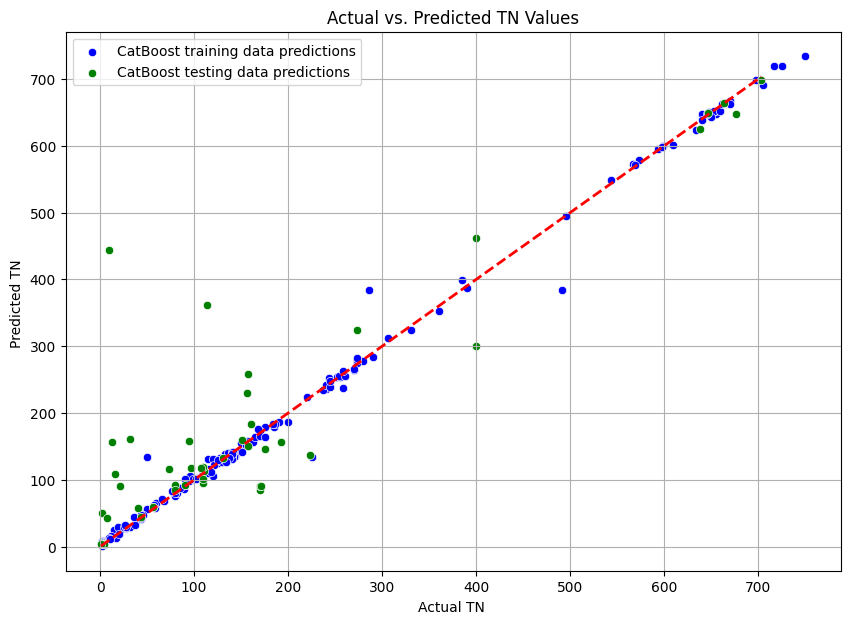

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_train_2, y=pred_cat_train_2, color='blue', label='CatBoost training data predictions')
sns.scatterplot(x=y_test_2, y=pred_cat_test_2, color='green', label='CatBoost testing data predictions')
plt.plot([y_test_2.min(), y_test_2.max()], [y_test_2.min(), y_test_2.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel("Actual TN ")
plt.ylabel("Predicted TN ")
plt.title("Actual vs. Predicted TN Values")
plt.grid(True)
plt.show()


In [54]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    cat,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print(scores)
print(scores.mean())
print(scores.std())

[0.77605726 0.89170427 0.47488076 0.87946025 0.93061743]
0.7905439952879468
0.16589949548567673


In [55]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV

cat = CatBoostRegressor(
    verbose=0,
    random_seed=42
)

params = {
    "depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "iterations": [300, 500, 800, 1000],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    cat,
    params,
    cv=5,
    n_iter=25,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

search.fit(X, y)  #randomized search cv is already performing cross-validation, so we don't need to train only training data

print(search.best_score_)
print(search.best_params_)

0.5904637544517397
{'subsample': 0.7, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 6}


SHAP ANALYSIS: SHapley Additive exPlanations

In [57]:
pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   -- ------------------------------------- 2.1/41.9 MB 11.3 MB/s eta 0:00:04
   ---- ----------------------------------- 4.5/41.9 MB 10.9 MB/s eta 0:00:04
   ------ --------------------------------- 7.1/41.9 MB 11.1 MB/s eta 0:00:04
   -------- ------------------------------- 9.2/41.9 MB 11.1 MB/s eta 0:00:03
   ----------- ---------------------------- 11.5/41.9 MB 11.2 MB/s eta 0:00:03
   ------------- -------------------------- 13.9/41.9 MB 11.1 MB/s eta 0:00:03
   --------------- ------------------------ 16.3/41.9 MB 11.2 MB/s eta 0:00:03
   ------------------ --------------------- 18.9/41.9 MB 11.2 MB/s eta 0:00:03
   -------------------- ------------------- 21.2/41.9 MB 11.2 MB/s eta 0:00:02
   ---------------------- ----------------- 23.6/41.9 MB 11.2 MB/s eta 0:00:02
   ------------------------ --------------- 26.0/41.9 MB 11.2 MB/s eta 0:00:02
   --------------------------- ------------ 28.3/41.9 MB 11.2 MB/

In [84]:
import shap
cat.fit(X_train_2, y_train_2)

explainer = shap.TreeExplainer(cat)

shap_values_test = explainer.shap_values(X_test_2)

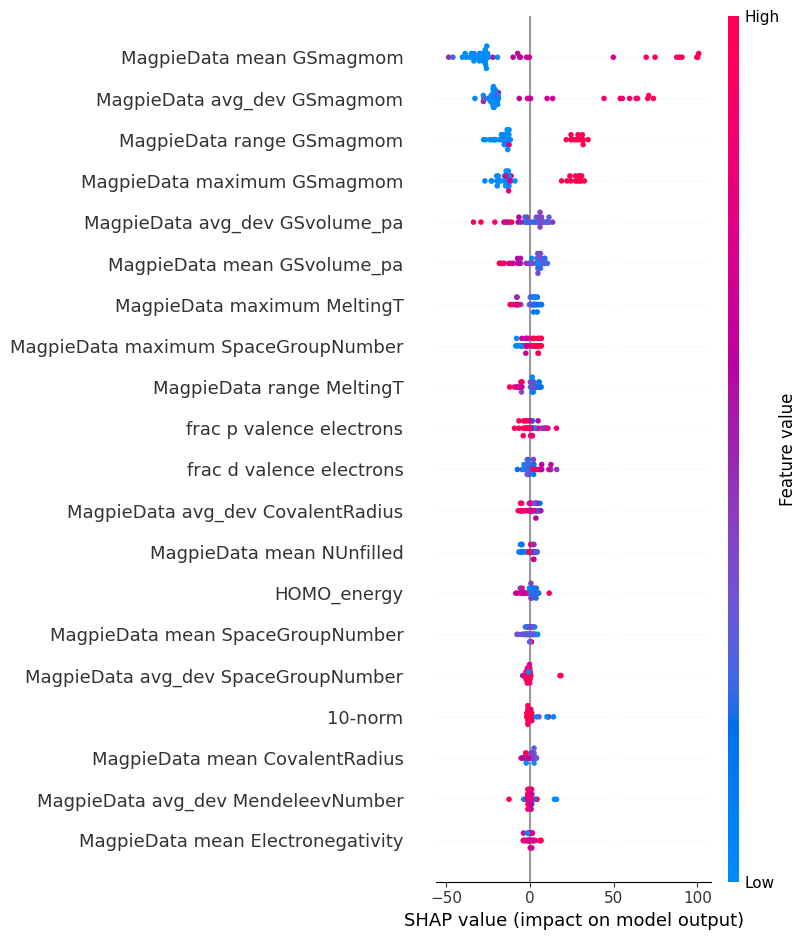

In [85]:
shap.summary_plot(shap_values_test, X_test_2)

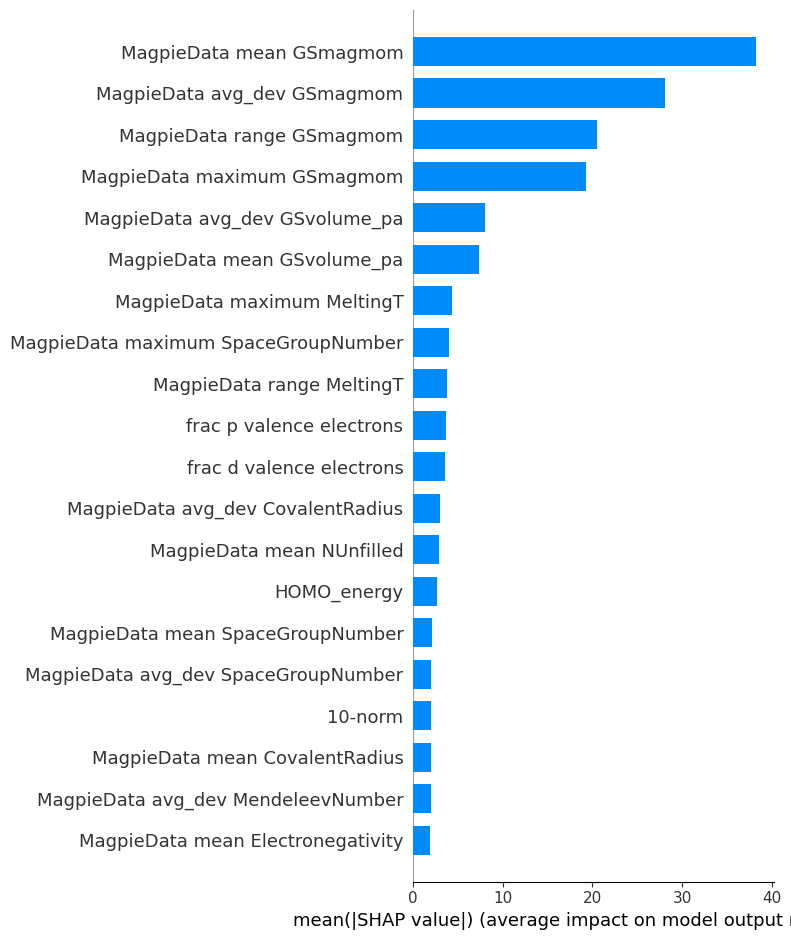

In [86]:
shap.summary_plot(
    shap_values_test,
    X_test_2,
    plot_type="bar"
)

physics interpretation using shap analysis on cat retrained model on entire x database without train test split

In [87]:
import shap
cat.fit(X, y)

explainer = shap.TreeExplainer(cat)

shap_values = explainer.shap_values(X)

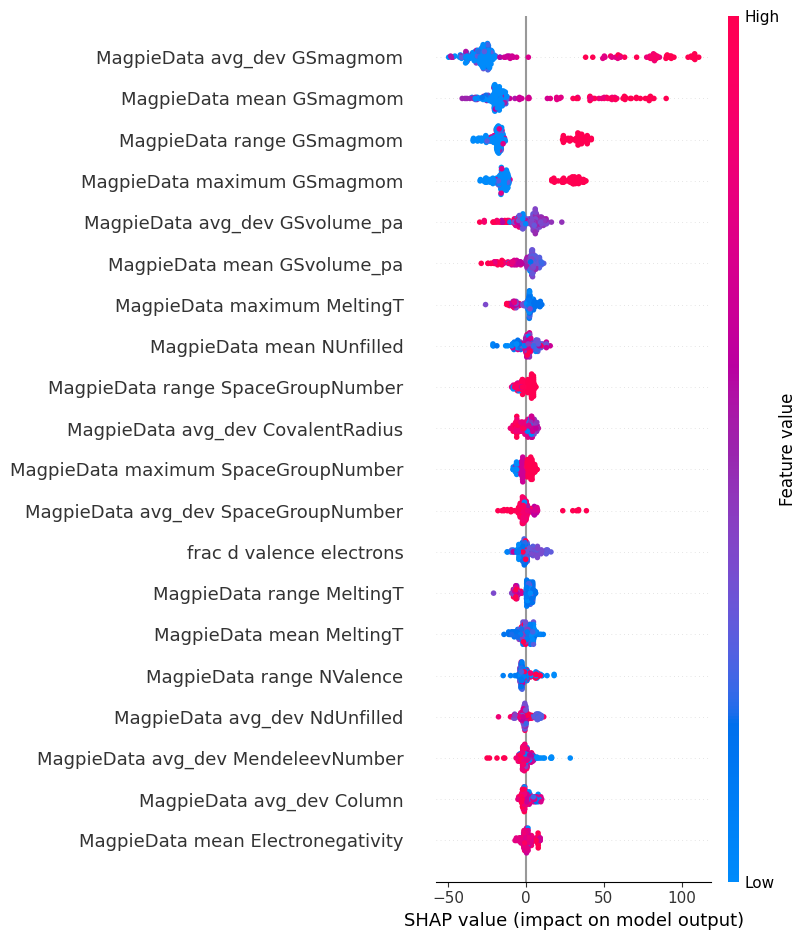

In [88]:
shap.summary_plot(shap_values, X)

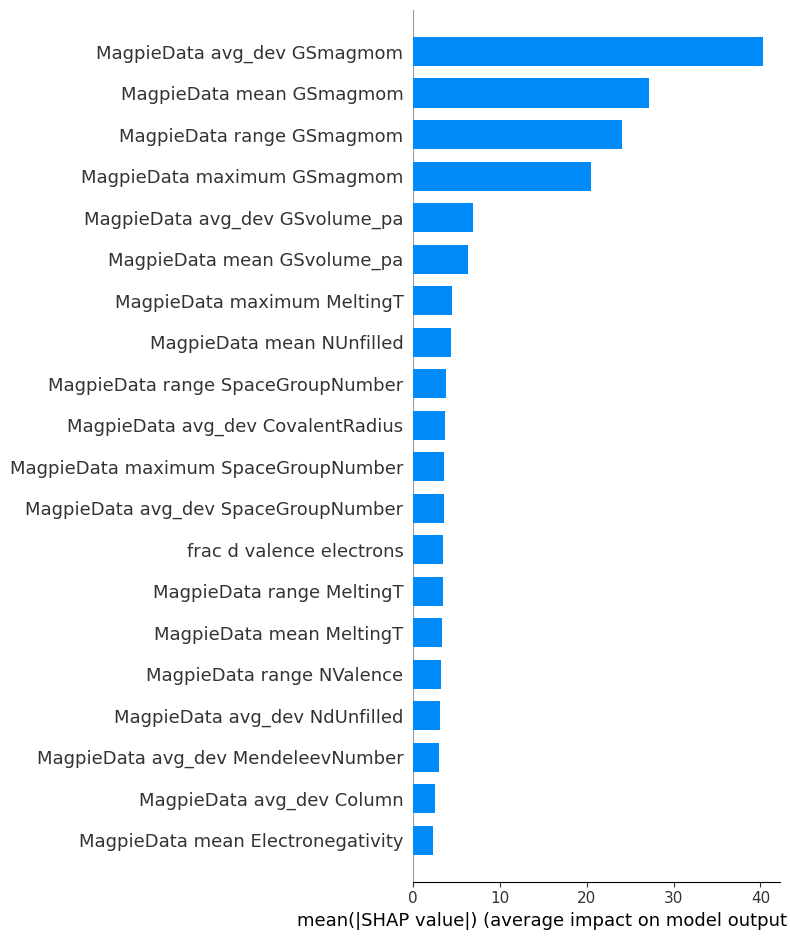

In [89]:
shap.summary_plot(
    shap_values,
    X_test_2,
    plot_type="bar"
)

top features in overall data using shap 

In [97]:
import numpy as np
import pandas as pd

# Mean absolute SHAP values
mean_shap = np.abs(shap_values).mean(axis=0)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": mean_shap
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(70))

                                  Feature  Importance
124           MagpieData avg_dev GSmagmom   40.237845
123              MagpieData mean GSmagmom   27.140439
122             MagpieData range GSmagmom   24.076044
121           MagpieData maximum GSmagmom   20.518764
112        MagpieData avg_dev GSvolume_pa    6.906726
..                                    ...         ...
46   MagpieData avg_dev Electronegativity    0.719279
38        MagpieData range CovalentRadius    0.707010
75               MagpieData mean NValence    0.685442
79          MagpieData maximum NsUnfilled    0.679652
132                                0-norm    0.675712

[70 rows x 2 columns]


In [98]:
top10 = importance.head(10)["Feature"].tolist()

top20 = importance.head(20)["Feature"].tolist()

top50 = importance.head(50)["Feature"].tolist()

In [99]:
X_all = X

X_top20 = X[top20]

X_top10 = X[top10]

X_top50 = X[top50]

In [100]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

models = {
    "RF": RandomForestRegressor(random_state=42),
    "ET": ExtraTreesRegressor(random_state=42),
    "XGB": XGBRegressor(random_state=42),
    "Cat": CatBoostRegressor(verbose=0, random_seed=42)
}

In [101]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def evaluate(model, Xdata, y):
    scores = cross_val_score(
        model,
        Xdata,
        y,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )
    return scores.mean()

In [104]:
results = []

for name, model in models.items():

    r_all = evaluate(model, X_all, y)

    r20 = evaluate(model, X_top20, y)

    r10 = evaluate(model, X_top10, y)

    r50 = evaluate(model, X_top50, y)

    results.append([name, r_all, r20, r10, r50])

results = pd.DataFrame(
    results,
    columns=["Model", "All", "Top20", "Top10", "Top50"]
)

print(results)

  Model       All     Top20     Top10     Top50
0    RF  0.703831  0.724687  0.699880  0.717130
1    ET  0.751749  0.764423  0.764741  0.772638
2   XGB  0.661661  0.699924  0.683722  0.669517
3   Cat  0.790544  0.790791  0.744107  0.799943


In [111]:
labels = results["Model"]
x = np.arange(len(labels))
print(x)

[0 1 2 3]


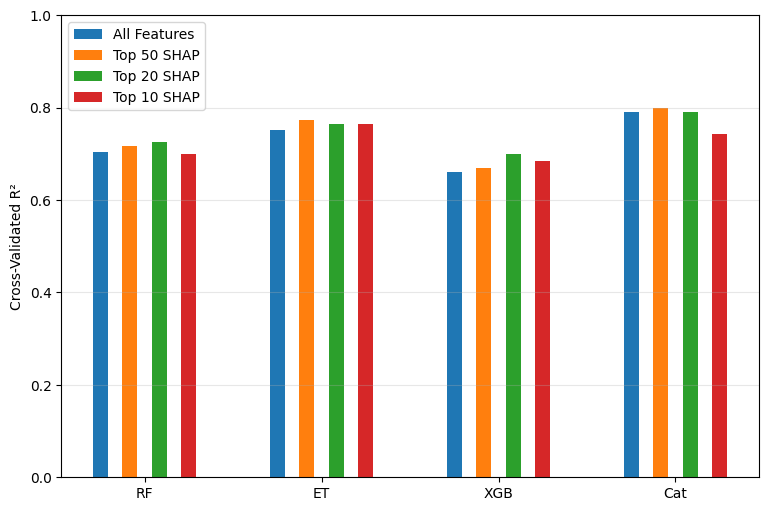

In [126]:
import numpy as np
import matplotlib.pyplot as plt

labels = results["Model"]

x = np.arange(len(labels))*3

width = 0.25

plt.figure(figsize=(9,6))

plt.bar(
    x-3*width,
    results["All"],
    width,
    label="All Features"
)

plt.bar(
    x-width,
    results["Top50"],
    width,
    label="Top 50 SHAP"
)

plt.bar(
    x+width,
    results["Top20"],
    width,
    label="Top 20 SHAP"
)

plt.bar(
    x+3*width,
    results["Top10"],
    width,
    label="Top 10 SHAP"
)

plt.xticks(x, labels)

plt.ylabel("Cross-Validated R²")

plt.ylim(0,1)

plt.legend()

plt.grid(axis="y", alpha=0.3)



plt.show()